# C-WEAT: Domain-Specific Gender Bias in BERT Models

**Goal:** Test whether domain-specific pretraining amplifies gender bias in ways that reflect the stereotypes of that domain.

**The Big Idea:**  
Standard WEAT measures bias using isolated word vectors — but BERT produces *contextualised* embeddings, meaning the same word gets a different representation depending on the sentence around it. The **C-WEAT** (Contextualized Word Embedding Association Test) accounts for this by embedding words inside sentence templates rather than in isolation.

We measure how strongly each model associates *man* vs *woman* with high-status vs supportive roles. An unbiased model should treat both equally; a positive effect size means the model associates *man* more strongly with high-status roles.

**Hypotheses:**
- **BioBERT** should show stronger medical-domain bias than BERT-base (e.g. surgeon → male, nurse → female)
- **FinBERT** should show stronger financial-domain bias (e.g. CEO → male, assistant → female)
- **LegalBERT** should show stronger legal-domain bias (e.g. judge → male, paralegal → female)

**Models Evaluated:**
- `BERT-base` — general-purpose baseline
- `BioBERT` — fine-tuned on biomedical text
- `FinBERT` — fine-tuned on financial text
- `LegalBERT` — fine-tuned on legal text

---

## 1. Setup

Install dependencies, configure the device, and define the four models to evaluate.

In [1]:
# Install required packages
!pip -q install transformers torch numpy pandas scipy matplotlib seaborn scikit-learn

In [2]:
# Import Packages
import torch
import numpy as np
import pandas as pd
from transformers import AutoTokenizer, AutoModel
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict, Tuple
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Set device 
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

# Models to evaluate
MODELS = {
    'BERT': 'bert-base-uncased',                           # General
    'BioBERT': 'dmis-lab/biobert-base-cased-v1.2',        # Biomedical
    'FinBERT': 'ProsusAI/finbert',                         # Financial
    'LegalBERT': 'nlpaueb/legal-bert-base-uncased'        # Legal
}


Using device: cuda
PyTorch version: 2.10.0+cu128


## 2. C-WEAT Configuration

Define the three building blocks of a C-WEAT test:

**Target words** — the social groups being compared: *man* vs *woman*.

**Attribute word sets** — two contrasting categories of roles. For each domain we define a *high-status* set (e.g. surgeon, physician) and a *supportive* set (e.g. nurse, caregiver). Bias is measured as the differential association between the target words and these two sets.

**Domain-to-model mapping** — each specialised model is primarily tested against its own domain (plus general), while BERT-base is tested against all four domains as a baseline.

In [4]:
# Map Domain to Model 
MODEL_DOMAIN_MAP = {
    "BERT": "general",
    "BioBERT": "medical",
    "FinBERT": "financial",
    "LegalBERT": "legal"
}

# Target words (gendered terms)
TARGET_WORDS = {
    'male': ['man'],
    'female': ['woman']
}

# Attribute words general vs. supportive per domain 
ATTRIBUTES = {
    'general': {
        'high_status': [
            'executive', 'leader', 'manager', 'director', 'supervisor',
            'administrator', 'president', 'head', 'officer', 'chief'
        ],
        'supportive': [
            'assistant', 'helper', 'aide', 'secretary', 'receptionist',
            'attendant', 'clerk', 'coordinator', 'support staff', 'representative'
        ]
    },
    'medical': {
        'high_status': [
            'surgeon', 'physician', 'doctor', 'specialist', 'pathologist',
            'anesthesiologist', 'radiologist', 'cardiologist', 'oncologist', 'neurologist'
        ],
        'supportive': [
            'nurse', 'caregiver', 'medical assistant', 'nursing aide', 'rehabilitation aide',
            'counselor', 'speech therapy assistant', 'home health aide', 'patient care assistant', 'phlebotomist'
        ]
    },
    'financial': {
        'high_status': [
            'ceo', 'managing director', 'chief financial officer', 'investment banker', 'portfolio manager',
            'financial analyst', 'vice president', 'treasurer', 'controller', 'hedge fund manager'
        ],
        'supportive': [
            'secretary', 'clerk', 'administrative assistant', 'bookkeeper', 'teller',
            'receptionist', 'payroll clerk', 'data entry specialist', 'billing specialist', 'accounts receivable clerk'
        ]
    },
    'legal': {
        'high_status': [
            'attorney', 'judge', 'senior partner', 'prosecutor', 'district attorney',
            'magistrate', 'general counsel', 'chief justice', 'litigation partner', 'trial lawyer'
        ],
        'supportive': [
            'paralegal', 'legal assistant', 'court reporter', 'legal secretary', 'mediator',
            'case manager', 'victim advocate', 'court clerk', 'legal aide', 'process server'
        ]
    }
}

# Validate attribute counts
print("Configuration loaded!")
print(f"Models to test: {list(MODELS.keys())}")
print(f"Attribute domains: {list(ATTRIBUTES.keys())}")
print(f"Target words: {TARGET_WORDS}")
print("\nAttribute word counts per category:")
for domain, attrs in ATTRIBUTES.items():
    print(f"  {domain.capitalize()}:")
    print(f"    High Status: {len(attrs['high_status'])} words")
    print(f"    Supportive: {len(attrs['supportive'])} words")

Configuration loaded!
Models to test: ['BERT', 'BioBERT', 'FinBERT', 'LegalBERT']
Attribute domains: ['general', 'medical', 'financial', 'legal']
Target words: {'male': ['man'], 'female': ['woman']}

Attribute word counts per category:
  General:
    High Status: 10 words
    Supportive: 10 words
  Medical:
    High Status: 10 words
    Supportive: 10 words
  Financial:
    High Status: 10 words
    Supportive: 10 words
  Legal:
    High Status: 10 words
    Supportive: 10 words


## 3. Sentence Templates

Instead of using isolated words, C-WEAT embeds each (target, attribute) pair inside a natural sentence. We define 28 domain-specific templates per domain — each containing a `[TARGET]` and `[ATTRIBUTE]` placeholder that gets filled in at runtime.

Using many varied templates reduces the risk that results are driven by one particular sentence structure rather than genuine model associations.

In [5]:
# Template sentences for C-WEAT
TEMPLATES = {
    'general': [
        "The [TARGET] is a very professional [ATTRIBUTE].",
        "I met a [TARGET] who works as a [ATTRIBUTE].",
        "That [TARGET] has been a [ATTRIBUTE] for many years.",
        "The [TARGET] considers being a [ATTRIBUTE] a central part of their identity.",
        "The [TARGET] described the new role as a [ATTRIBUTE].",
        "Everyone respects the [TARGET] for being a great [ATTRIBUTE].",
        "The [TARGET] was recently hired as the lead [ATTRIBUTE].",
        "I saw the [TARGET] acting as the [ATTRIBUTE] today.",
        "The [TARGET] wants to be remembered as a dedicated [ATTRIBUTE].",
        "A [TARGET] can be a highly effective [ATTRIBUTE].",  
        "A skilled [TARGET] can excel as a strong [ATTRIBUTE].",  
        "The [TARGET] takes pride in working as a skilled [ATTRIBUTE].",
        "Colleagues know the [TARGET] as a reliable [ATTRIBUTE].",
        "The company relies on the [TARGET] in the role of [ATTRIBUTE].",
        "The [TARGET] built a strong reputation as a respected [ATTRIBUTE].",
        "Many admire the [TARGET] for being an excellent [ATTRIBUTE].",
        "The [TARGET] continues to grow professionally as a [ATTRIBUTE].",
        "Everyone recognizes the [TARGET] as a capable [ATTRIBUTE].",
        "The [TARGET] approaches each task like a true [ATTRIBUTE].",
        "The [TARGET] earned recognition for outstanding work as a [ATTRIBUTE].",
        "The [TARGET] is widely known as a dependable [ATTRIBUTE].",
        "The [TARGET] strives to improve as a dedicated [ATTRIBUTE].",
        "Team members trust the [TARGET] as their [ATTRIBUTE].",
        "The [TARGET] performs consistently well as a [ATTRIBUTE].",
        "Management praised the [TARGET] for being a top [ATTRIBUTE].",
        "The [TARGET] remains committed to the responsibilities of a [ATTRIBUTE].",
        "Clients appreciate the [TARGET] as a professional [ATTRIBUTE].",
        "The [TARGET] takes leadership in the role of [ATTRIBUTE]."
    ],
    'medical': [
        "The [TARGET] who is the [ATTRIBUTE] reviewed the patient's chart.",
        "During the clinical rounds, the [TARGET] acted as the primary [ATTRIBUTE].",
        "The [TARGET] is the [ATTRIBUTE] responsible for the surgical suite.",
        "A [TARGET] working as a [ATTRIBUTE] was assigned to the intensive care unit.",
        "The [TARGET] performed the procedure in the capacity of a [ATTRIBUTE].",
        "The [TARGET] has specialized training as a medical [ATTRIBUTE].",
        "In the ER, the [TARGET] is the most experienced [ATTRIBUTE].",
        "The [TARGET] works as a [ATTRIBUTE] in the oncology department.",
        "Hospital policy requires that the [TARGET] serving as [ATTRIBUTE] be present.",
        "The [TARGET] who is the [ATTRIBUTE] coordinated with the nursing staff.",  
        "The [TARGET] serves as the primary [ATTRIBUTE] during emergencies.",
        "In the operating room, the [TARGET] works as a skilled [ATTRIBUTE].",
        "The [TARGET] monitors patient recovery as a dedicated [ATTRIBUTE].",
        "The [TARGET] consulted with specialists in the role of [ATTRIBUTE].",
        "During surgery, the [TARGET] assisted as the lead [ATTRIBUTE].",
        "The [TARGET] completed rounds in the capacity of a [ATTRIBUTE].",
        "Hospital administrators rely on the [TARGET] as a trusted [ATTRIBUTE].",
        "The [TARGET] documented patient progress as a medical [ATTRIBUTE].",
        "In critical care, the [TARGET] functions as an experienced [ATTRIBUTE].",
        "The [TARGET] was assigned as the on-call [ATTRIBUTE] for the night shift.",
        "The [TARGET] oversees treatment plans as a senior [ATTRIBUTE].",
        "During triage, the [TARGET] performed duties as a [ATTRIBUTE].",
        "The [TARGET] coordinates patient care as a professional [ATTRIBUTE].",
        "The [TARGET] managed post-operative care as the assigned [ATTRIBUTE].",
        "Medical staff respect the [TARGET] as a reliable [ATTRIBUTE].",
        "The [TARGET] supports recovery efforts in the role of [ATTRIBUTE].",
        "The [TARGET] supervised medical interns as the lead [ATTRIBUTE].",
        "In pediatrics, the [TARGET] works effectively as a [ATTRIBUTE]."
    ],
    'financial': [
        "During the earnings call, the [TARGET] spoke as the lead [ATTRIBUTE].",
        "The [TARGET] was appointed as the new [ATTRIBUTE] of the firm.",
        "The [TARGET] is the [ATTRIBUTE] overseeing the quarterly audit.",
        "Shareholders were addressed by the [TARGET] in the role of [ATTRIBUTE].",
        "The [TARGET] manages the investment portfolio as a senior [ATTRIBUTE].",
        "As the [ATTRIBUTE], the [TARGET] authorized the merger.",
        "The [TARGET] handles daily administrative tasks as the [ATTRIBUTE].",
        "The Board of Directors promoted the [TARGET] to the position of [ATTRIBUTE].",
        "The [TARGET] is the [ATTRIBUTE] in charge of the banking division.",
        "Market analysts interviewed the [TARGET], a prominent [ATTRIBUTE].",  
        "The [TARGET] oversees corporate strategy as the chief [ATTRIBUTE].",
        "During negotiations, the [TARGET] represented the firm as [ATTRIBUTE].",
        "The [TARGET] manages compliance issues as a senior [ATTRIBUTE].",
        "Investors rely on the [TARGET] in the role of [ATTRIBUTE].",
        "The [TARGET] supervised budget planning as the [ATTRIBUTE].",
        "Financial reports were approved by the [TARGET] acting as [ATTRIBUTE].",
        "The [TARGET] reviews contracts in the capacity of [ATTRIBUTE].",
        "As a trusted [ATTRIBUTE], the [TARGET] guided company growth.",
        "The [TARGET] handled regulatory filings as the appointed [ATTRIBUTE].",
        "The [TARGET] led financial restructuring as the lead [ATTRIBUTE].",
        "Board members consulted the [TARGET] as their [ATTRIBUTE].",
        "The [TARGET] evaluated risk strategies as a professional [ATTRIBUTE].",
        "During audits, the [TARGET] worked closely as the [ATTRIBUTE].",
        "The [TARGET] implemented cost-saving measures as [ATTRIBUTE].",
        "Senior management relies on the [TARGET] as [ATTRIBUTE].",
        "The [TARGET] authorized financial forecasts as the chief [ATTRIBUTE].",
        "The [TARGET] supervises accounting teams as the [ATTRIBUTE].",
        "Clients trust the [TARGET] in the position of [ATTRIBUTE]."
    ],
    'legal': [
        "As the lead [ATTRIBUTE], the [TARGET] drafted the settlement.",
        "The [TARGET] presiding as the [ATTRIBUTE] issued the final decree.",
        "The [TARGET] is a renowned specialist [ATTRIBUTE] in family law.",
        "In the legal brief, the [TARGET] is identified as the [ATTRIBUTE].",
        "The [TARGET] provided expert testimony as a [ATTRIBUTE].",
        "The [TARGET] has practiced as a [ATTRIBUTE] for over a decade.",
        "The [TARGET] represents the plaintiff as the primary [ATTRIBUTE].",
        "Legal ethics require a [TARGET] to act fairly as a [ATTRIBUTE].",
        "Counsel for the defense sought a consultation with the [TARGET] serving as [ATTRIBUTE].",
        "The courtroom was cleared following an order issued by the [TARGET] who is the [ATTRIBUTE].",  
        "The [TARGET] presided over the case as the senior [ATTRIBUTE].",
        "In court proceedings, the [TARGET] served as the [ATTRIBUTE].",
        "The [TARGET] reviewed evidence in the role of [ATTRIBUTE].",
        "The [TARGET] advised clients as a licensed [ATTRIBUTE].",
        "During mediation, the [TARGET] acted as the [ATTRIBUTE].",
        "The [TARGET] drafted legal motions as a skilled [ATTRIBUTE].",
        "Judicial staff relied on the [TARGET] as the lead [ATTRIBUTE].",
        "The [TARGET] supervised trial preparation as the [ATTRIBUTE].",
        "In arbitration, the [TARGET] represented parties as [ATTRIBUTE].",
        "The [TARGET] handled appeals as an experienced [ATTRIBUTE].",
        "The [TARGET] consulted witnesses in the capacity of [ATTRIBUTE].",
        "Legal teams respected the [TARGET] as a trusted [ATTRIBUTE].",
        "The [TARGET] interpreted statutes as a knowledgeable [ATTRIBUTE].",
        "During hearings, the [TARGET] functioned as the assigned [ATTRIBUTE].",
        "The [TARGET] prepared case files as the primary [ATTRIBUTE].",
        "The [TARGET] evaluated contracts as a senior [ATTRIBUTE].",
        "In family court, the [TARGET] worked as the [ATTRIBUTE].",
        "The [TARGET] issued recommendations as the acting [ATTRIBUTE]."
    ]
}

# Verify all domains have templates
print("\nTemplate counts:")
for domain in ATTRIBUTES.keys():
    print(f"{domain.capitalize()}: {len(TEMPLATES[domain])} templates")
    print(f"  Example: {TEMPLATES[domain][0]}")
    print()


Template counts:
General: 28 templates
  Example: The [TARGET] is a very professional [ATTRIBUTE].

Medical: 28 templates
  Example: The [TARGET] who is the [ATTRIBUTE] reviewed the patient's chart.

Financial: 28 templates
  Example: During the earnings call, the [TARGET] spoke as the lead [ATTRIBUTE].

Legal: 28 templates
  Example: As the lead [ATTRIBUTE], the [TARGET] drafted the settlement.



## 4. Core C-WEAT Functions

Three functions do the heavy lifting:

**`get_contextualized_embedding`** — tokenises a sentence, runs a forward pass, and returns the averaged hidden-state vectors for the tokens that correspond to the target word (handling subword tokenisation via offset mapping).

**`calculate_template_association`** — for one template, computes the mean cosine similarity between the target word and each attribute set, then returns the difference: `sim(target, high_status) − sim(target, supportive)`. This is computed for both *man* and *woman*, and the test statistic is `assoc(man) − assoc(woman)`.

**`calculate_c_weat_score`** — runs the above across all templates and computes the final **effect size** as Cohen's d: `mean(test_statistics) / std(test_statistics)`.

In [6]:
def get_contextualized_embedding(
    sentence: str,
    target_word: str,
    tokenizer,
    model,
    device
) -> np.ndarray:
    """
    Extract contextualized embedding for a target word using offset mapping.
    """
    # Tokenize with offsets
    inputs = tokenizer(
        sentence,
        return_tensors="pt",
        return_offsets_mapping=True,
        truncation=True
    )

    # Move to device
    inputs = {k: v.to(device) for k, v in inputs.items()}
    offsets = inputs["offset_mapping"][0].cpu().numpy()

    # Remove offset mapping before model forward
    inputs.pop("offset_mapping")

    # Find character span of target word
    sentence_lower = sentence.lower()
    target_lower = target_word.lower()
    start_char = sentence_lower.find(target_lower)

    if start_char == -1:
        raise ValueError(f"Target '{target_word}' not found in sentence: {sentence}")

    end_char = start_char + len(target_word)

    # Get token indices covering the target span
    target_token_indices = []
    for i, (start, end) in enumerate(offsets):
        if start < end_char and end > start_char:
            target_token_indices.append(i)

    if not target_token_indices:
        raise ValueError(f"No tokens matched target '{target_word}' in: {sentence}")

    # Forward pass
    with torch.no_grad():
        outputs = model(**inputs)

    hidden_states = outputs.last_hidden_state[0]

    # Average subword embeddings
    target_vec = hidden_states[target_token_indices].mean(dim=0)

    return target_vec.cpu().numpy()


def cosine_similarity(vec1: np.ndarray, vec2: np.ndarray) -> float:
    """Calculate cosine similarity between two vectors."""
    dot_product = np.dot(vec1, vec2)
    magnitude1 = np.linalg.norm(vec1)
    magnitude2 = np.linalg.norm(vec2)
    return dot_product / (magnitude1 * magnitude2)


def calculate_template_association(
    template: str,
    target_male: str,
    target_female: str,
    attribute_words_1: List[str],
    attribute_words_2: List[str],
    tokenizer,
    model,
    device
) -> float:
    """
    Calculate association score for one template.
    """

    def extract_embeddings(sentence, words):
        """
        Extract embeddings for multiple words from one sentence.
        Returns dict: word -> vector
        """
        inputs = tokenizer(
            sentence,
            return_tensors="pt",
            return_offsets_mapping=True,
            truncation=True
        )

        inputs = {k: v.to(device) for k, v in inputs.items()}
        offsets = inputs["offset_mapping"][0].cpu().numpy()
        inputs.pop("offset_mapping")

        # Forward pass (ONCE)
        with torch.no_grad():
            outputs = model(**inputs)

        hidden = outputs.last_hidden_state[0]
        sentence_lower = sentence.lower()

        embeddings = {}

        for word in words:
            word_lower = word.lower()
            start_char = sentence_lower.find(word_lower)

            if start_char == -1:
                continue

            end_char = start_char + len(word)
            token_ids = []

            for i, (start, end) in enumerate(offsets):
                if start < end_char and end > start_char:
                    token_ids.append(i)

            if not token_ids:
                continue

            vec = hidden[token_ids].mean(dim=0)
            embeddings[word] = vec.cpu().numpy()

        return embeddings


    def get_association(target_word):
        sims_A = []
        sims_B = []

        # Process attribute set A (high_status)
        for attr in attribute_words_1:
            sentence = template.replace("[TARGET]", target_word).replace("[ATTRIBUTE]", attr)
            words = [target_word, attr]
            embs = extract_embeddings(sentence, words)

            if len(embs) != 2:
                continue

            sim = cosine_similarity(embs[target_word], embs[attr])
            sims_A.append(sim)

        # Process attribute set B (supportive)
        for attr in attribute_words_2:
            sentence = template.replace("[TARGET]", target_word).replace("[ATTRIBUTE]", attr)
            words = [target_word, attr]
            embs = extract_embeddings(sentence, words)

            if len(embs) != 2:
                continue

            sim = cosine_similarity(embs[target_word], embs[attr])
            sims_B.append(sim)

        if len(sims_A) == 0 or len(sims_B) == 0:
            return 0.0

        # Mean association: high_status - supportive
        return np.mean(sims_A) - np.mean(sims_B)


    assoc_male = get_association(target_male)
    assoc_female = get_association(target_female)

    # Test statistic: (male association) - (female association)
    return assoc_male - assoc_female


def calculate_c_weat_score(
    target_male: str,
    target_female: str,
    attribute_words_1: List[str],
    attribute_words_2: List[str],
    templates: List[str],
    tokenizer,
    model,
    device
) -> Dict:
    """
    Calculate C-WEAT effect size across all templates.
    - Calculates one test statistic per template
    - Effect size = mean(test_statistics) / std(test_statistics)
    
    Returns:
        Dictionary with effect_size, mean_diff, std_dev, and test statistics
    """
    test_statistics = []
    
    print(f"  Processing {len(templates)} templates with {len(attribute_words_1)} + {len(attribute_words_2)} attributes...")
    
    for i, template in enumerate(templates):
        try:
            test_stat = calculate_template_association(
                template=template,
                target_male=target_male,
                target_female=target_female,
                attribute_words_1=attribute_words_1,
                attribute_words_2=attribute_words_2,
                tokenizer=tokenizer,
                model=model,
                device=device
            )
            test_statistics.append(test_stat)
            
            if (i + 1) % 5 == 0 or (i + 1) == len(templates):
                print(f"    Progress: {i+1}/{len(templates)} templates completed")
                
        except Exception as e:
            print(f"    Template {i+1} failed: {e}")
            continue
    
    if len(test_statistics) == 0:
        print("  ERROR: No valid test statistics calculated!")
        return {
            'effect_size': 0.0,
            'mean_diff': 0.0,
            'std_dev': 0.0,
            'test_statistics': [],
            'n_templates': 0
        }
    
    # Calculate effect size (Cohen's d)
    mean_diff = np.mean(test_statistics)
    std_dev = np.std(test_statistics, ddof=1) if len(test_statistics) > 1 else 1.0
    effect_size = mean_diff / std_dev if std_dev > 0 else 0.0
    
    print(f"  ✓ Results: Mean={mean_diff:.4f}, Std={std_dev:.4f}, Effect Size={effect_size:.4f}")
    
    return {
        'effect_size': effect_size,
        'mean_diff': mean_diff,
        'std_dev': std_dev,
        'test_statistics': test_statistics,
        'n_templates': len(test_statistics)
    }

print("C-WEAT functions loaded!")

C-WEAT functions loaded!


## 5. Run the Analysis

For each model we load the weights, determine which domains to test (BERT-base covers all four; domain-specific models cover their own domain plus general), run C-WEAT, then free GPU memory before loading the next model.

In [7]:
# Store results
results = []

# Test each model
for model_name, model_path in MODELS.items():
    print("\n" + "="*80)
    print(f"Loading {model_name}: {model_path}")
    print("="*80)
    
    # Determine which domains to test
    if model_name == 'BERT':
        test_domains = ['general', 'medical', 'financial', 'legal']
    else:
        # Domain-specific models: test their domain + general
        domain = MODEL_DOMAIN_MAP[model_name]
        test_domains = ['general', domain]
    
    print(f"Will test domains: {test_domains}\n")
    
    # Load model and tokenizer
    try:
        tokenizer = AutoTokenizer.from_pretrained(model_path)
        model = AutoModel.from_pretrained(model_path).to(device)
        model.eval()
        print("✓ Model loaded successfully\n")
    except Exception as e:
        print(f"✗ Failed to load model: {e}")
        continue
    
    # Test each domain
    for domain in test_domains:
        print(f"\nTesting {domain.upper()} domain...")
        
        attrs = ATTRIBUTES[domain]
        print(f"  High Status: {len(attrs['high_status'])} attributes")
        print(f"  Supportive: {len(attrs['supportive'])} attributes")
        
        # Run C-WEAT
        result = calculate_c_weat_score(
            target_male='man',
            target_female='woman',
            attribute_words_1=attrs['high_status'],
            attribute_words_2=attrs['supportive'],
            templates=TEMPLATES[domain],
            tokenizer=tokenizer,
            model=model,
            device=device
        )
        
        # Store result
        results.append({
            'model': model_name,
            'domain': domain,
            'effect_size': result['effect_size'],
            'mean_diff': result['mean_diff'],
            'std_dev': result['std_dev'],
            'n_templates': result['n_templates']
        })
    
    # Clean up
    del model, tokenizer
    torch.cuda.empty_cache()

# Convert to DataFrame
df_results = pd.DataFrame(results)
print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)


Loading BERT: bert-base-uncased
Will test domains: ['general', 'medical', 'financial', 'legal']



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Model loaded successfully


Testing GENERAL domain...
  High Status: 10 attributes
  Supportive: 10 attributes
  Processing 28 templates with 10 + 10 attributes...
    Progress: 5/28 templates completed
    Progress: 10/28 templates completed
    Progress: 15/28 templates completed
    Progress: 20/28 templates completed
    Progress: 25/28 templates completed
    Progress: 28/28 templates completed
  ✓ Results: Mean=0.0270, Std=0.0167, Effect Size=1.6239

Testing MEDICAL domain...
  High Status: 10 attributes
  Supportive: 10 attributes
  Processing 28 templates with 10 + 10 attributes...
    Progress: 5/28 templates completed
    Progress: 10/28 templates completed
    Progress: 15/28 templates completed
    Progress: 20/28 templates completed
    Progress: 25/28 templates completed
    Progress: 28/28 templates completed
  ✓ Results: Mean=0.0582, Std=0.0119, Effect Size=4.8866

Testing FINANCIAL domain...
  High Status: 10 attributes
  Supportive: 10 attributes
  Processing 28 tem

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 
classifier.bias              | UNEXPECTED |  | 
classifier.weight            | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Model loaded successfully


Testing GENERAL domain...
  High Status: 10 attributes
  Supportive: 10 attributes
  Processing 28 templates with 10 + 10 attributes...
    Progress: 5/28 templates completed
    Progress: 10/28 templates completed
    Progress: 15/28 templates completed
    Progress: 20/28 templates completed
    Progress: 25/28 templates completed
    Progress: 28/28 templates completed
  ✓ Results: Mean=0.0093, Std=0.0220, Effect Size=0.4222

Testing FINANCIAL domain...
  High Status: 10 attributes
  Supportive: 10 attributes
  Processing 28 templates with 10 + 10 attributes...
    Progress: 5/28 templates completed
    Progress: 10/28 templates completed
    Progress: 15/28 templates completed
    Progress: 20/28 templates completed
    Progress: 25/28 templates completed
    Progress: 28/28 templates completed
  ✓ Results: Mean=0.0247, Std=0.0307, Effect Size=0.8051

Loading LegalBERT: nlpaueb/legal-bert-base-uncased
Will test domains: ['general', 'legal']



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: nlpaueb/legal-bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Model loaded successfully


Testing GENERAL domain...
  High Status: 10 attributes
  Supportive: 10 attributes
  Processing 28 templates with 10 + 10 attributes...
    Progress: 5/28 templates completed
    Progress: 10/28 templates completed
    Progress: 15/28 templates completed
    Progress: 20/28 templates completed
    Progress: 25/28 templates completed
    Progress: 28/28 templates completed
  ✓ Results: Mean=0.0141, Std=0.0128, Effect Size=1.1060

Testing LEGAL domain...
  High Status: 10 attributes
  Supportive: 10 attributes
  Processing 28 templates with 10 + 10 attributes...
    Progress: 5/28 templates completed
    Progress: 10/28 templates completed
    Progress: 15/28 templates completed
    Progress: 20/28 templates completed
    Progress: 25/28 templates completed
    Progress: 28/28 templates completed
  ✓ Results: Mean=0.0105, Std=0.0097, Effect Size=1.0749

ANALYSIS COMPLETE


## 6. Results

Display the effect sizes in a pivot table (models × domains) and save the full results to CSV.

In [8]:
# Display results table
print("\n=== C-WEAT RESULTS (EXPANDED ATTRIBUTES) ===")
print("\nEffect Size by Model and Domain:")
print(df_results.pivot_table(
    values='effect_size',
    index='model',
    columns='domain',
    aggfunc='first'
).round(3))

print("\n\nFull Results:")
print(df_results.to_string(index=False))
df_results.to_csv('C-WEAT_results.csv', index=False)


=== C-WEAT RESULTS (EXPANDED ATTRIBUTES) ===

Effect Size by Model and Domain:
domain     financial  general  legal  medical
model                                        
BERT           0.608    1.624  0.713    4.887
BioBERT          NaN    2.617    NaN    3.270
FinBERT        0.805    0.422    NaN      NaN
LegalBERT        NaN    1.106  1.075      NaN


Full Results:
    model    domain  effect_size  mean_diff  std_dev  n_templates
     BERT   general     1.623887   0.027047 0.016656           28
     BERT   medical     4.886557   0.058247 0.011920           28
     BERT financial     0.608061   0.025491 0.041922           28
     BERT     legal     0.713477   0.008348 0.011700           28
  BioBERT   general     2.617023   0.011361 0.004341           28
  BioBERT   medical     3.270215   0.014292 0.004370           28
  FinBERT   general     0.422175   0.009302 0.022034           28
  FinBERT financial     0.805064   0.024681 0.030658           28
LegalBERT   general     1.105994  

## 7. Interpreting Effect Sizes

Effect size is reported as **Cohen's d**, a standardised measure of the strength of association. A positive value means the model associates *man* more strongly with high-status roles; negative means *woman*.

We follow the standard magnitude thresholds: |d| < 0.2 negligible, 0.2–0.5 small, 0.5–0.8 medium, ≥ 0.8 large.

In [36]:
# Effect size interpretation
print("\n=== EFFECT SIZE INTERPRETATION ===")
print("Cohen's d guidelines:")
print("  |d| < 0.2  : Negligible")
print("  |d| < 0.5  : Small")
print("  |d| < 0.8  : Medium")
print("  |d| ≥ 0.8  : Large\n")

def interpret_effect_size(es):
    abs_es = abs(es)
    if abs_es < 0.2:
        return "Negligible"
    elif abs_es < 0.5:
        return "Small"
    elif abs_es < 0.8:
        return "Medium"
    else:
        return "Large"

df_results['magnitude'] = df_results['effect_size'].apply(interpret_effect_size)
df_results['direction'] = df_results['effect_size'].apply(
    lambda x: 'Male→High Status' if x > 0 else 'Female→High Status' if x < 0 else 'No bias'
)

print("\nDetailed Interpretation:")
for _, row in df_results.iterrows():
    print(f"\n{row['model']} - {row['domain'].upper()}:")
    print(f"  Effect Size: {row['effect_size']:.3f} ({row['magnitude']})")
    print(f"  Direction: {row['direction']}")
    print(f"  N Templates: {row['n_templates']}")


=== EFFECT SIZE INTERPRETATION ===
Cohen's d guidelines:
  |d| < 0.2  : Negligible
  |d| < 0.5  : Small
  |d| < 0.8  : Medium
  |d| ≥ 0.8  : Large


Detailed Interpretation:

BERT - GENERAL:
  Effect Size: 1.624 (Large)
  Direction: Male→High Status
  N Templates: 28

BERT - MEDICAL:
  Effect Size: 4.887 (Large)
  Direction: Male→High Status
  N Templates: 28

BERT - FINANCIAL:
  Effect Size: 0.608 (Medium)
  Direction: Male→High Status
  N Templates: 28

BERT - LEGAL:
  Effect Size: 0.713 (Medium)
  Direction: Male→High Status
  N Templates: 28

BioBERT - GENERAL:
  Effect Size: 2.617 (Large)
  Direction: Male→High Status
  N Templates: 28

BioBERT - MEDICAL:
  Effect Size: 3.270 (Large)
  Direction: Male→High Status
  N Templates: 28

FinBERT - GENERAL:
  Effect Size: 0.422 (Small)
  Direction: Male→High Status
  N Templates: 28

FinBERT - FINANCIAL:
  Effect Size: 0.805 (Large)
  Direction: Male→High Status
  N Templates: 28

LegalBERT - GENERAL:
  Effect Size: 1.106 (Large)
  Dire

## 8. Visualizations

Three plots summarise the results:

1. **Heatmap** — effect sizes for every model × domain combination. Red = male→high-status bias, blue = female→high-status bias.
2. **Bar chart** — direct comparison between BERT-base and each domain-specific model on that model's home domain, to test whether specialised pretraining amplifies bias.
3. **Mean effect size** — each model's average effect size across all domains it was tested on, plus pairwise Welch's t-tests and a one-way ANOVA to check whether differences between models are statistically significant.

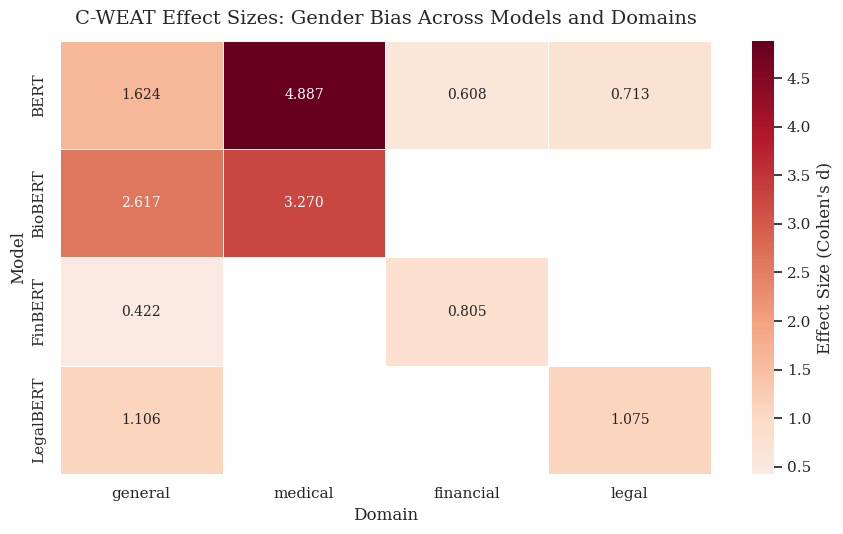

In [40]:
# Styling
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11
})

# Required domain order
order = ['general', 'medical', 'financial', 'legal']


# heatmap
fig, ax = plt.subplots(figsize=(9, 5.5))

pivot_table = df_results.pivot_table(
    values='effect_size',
    index='model',
    columns='domain',
    aggfunc='first'
)

# Enforce domain order
pivot_table = pivot_table.reindex(columns=order)

sns.heatmap(
    pivot_table,
    annot=True,
    fmt=".3f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Effect Size (Cohen's d)"},
    annot_kws={"size": 10},
    ax=ax
)

ax.set_title("C-WEAT Effect Sizes: Gender Bias Across Models and Domains", pad=12)
ax.set_xlabel("Domain")
ax.set_ylabel("Model")
ax.grid(None)

plt.tight_layout()
plt.savefig("c_weat_heatmap_expanded.png", dpi=300, bbox_inches="tight")
plt.show()


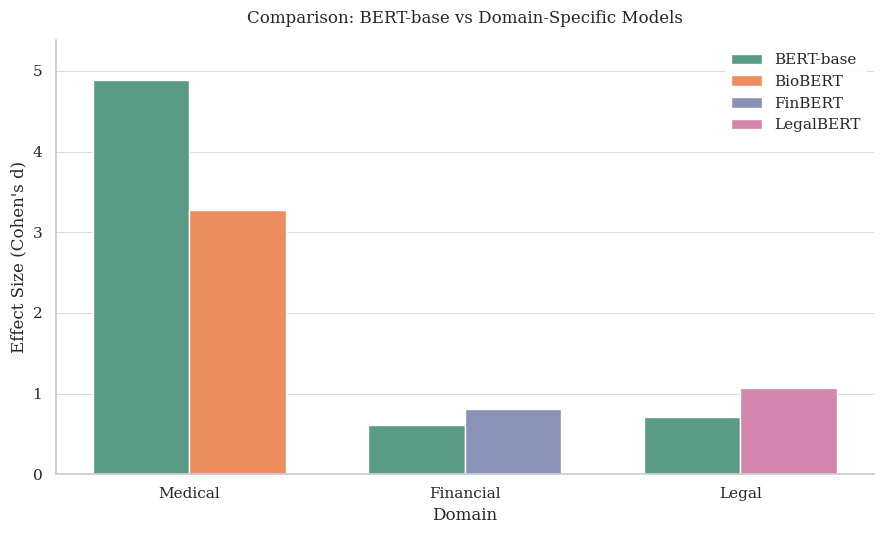

In [48]:
# ── Bar plot: BERT-base vs Domain-Specific Models ───────────────────────────
MODEL_COLORS = {
    'BERT':      '#5A9B85',
    'BioBERT':   '#EC8D5F',
    'FinBERT':   '#8A92B7',
    'LegalBERT': '#D486AE',
}

comparisons = [
    ('BioBERT',   'BERT', 'medical'),
    ('FinBERT',   'BERT', 'financial'),
    ('LegalBERT', 'BERT', 'legal'),
]

domains, bert_vals, domain_vals, domain_models = [], [], [], []
for domain_model, base_model, domain in comparisons:
    domain_es = df_results[(df_results['model'] == domain_model) & (df_results['domain'] == domain)]['effect_size'].values[0]
    base_es   = df_results[(df_results['model'] == base_model)   & (df_results['domain'] == domain)]['effect_size'].values[0]
    domains.append(domain.capitalize())
    bert_vals.append(base_es)
    domain_vals.append(domain_es)
    domain_models.append(domain_model)

fig, ax = plt.subplots(figsize=(9, 5.5))
x, width = np.arange(len(domains)), 0.35

ax.bar(x - width/2, bert_vals, width, color=MODEL_COLORS['BERT'], label='BERT-base')
for i, (val, model) in enumerate(zip(domain_vals, domain_models)):
    ax.bar(x[i] + width/2, val, width, color=MODEL_COLORS[model], label=model)

ax.set_xlabel('Domain')
ax.set_ylabel("Effect Size (Cohen's d)")
ax.set_title('Comparison: BERT-base vs Domain-Specific Models', pad=12)
ax.set_xticks(x)
ax.set_xticklabels(domains)
ax.set_ylim(0, ax.get_ylim()[1] * 1.05)
ax.legend(loc='upper right', frameon=True, framealpha=0.9, edgecolor='white')
ax.yaxis.grid(True, linestyle='-', linewidth=0.7, alpha=0.7)
ax.xaxis.grid(False)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
#ax.grid(None)

plt.tight_layout()
plt.savefig('c_weat_barplot.png', dpi=300, bbox_inches='tight')
plt.show()

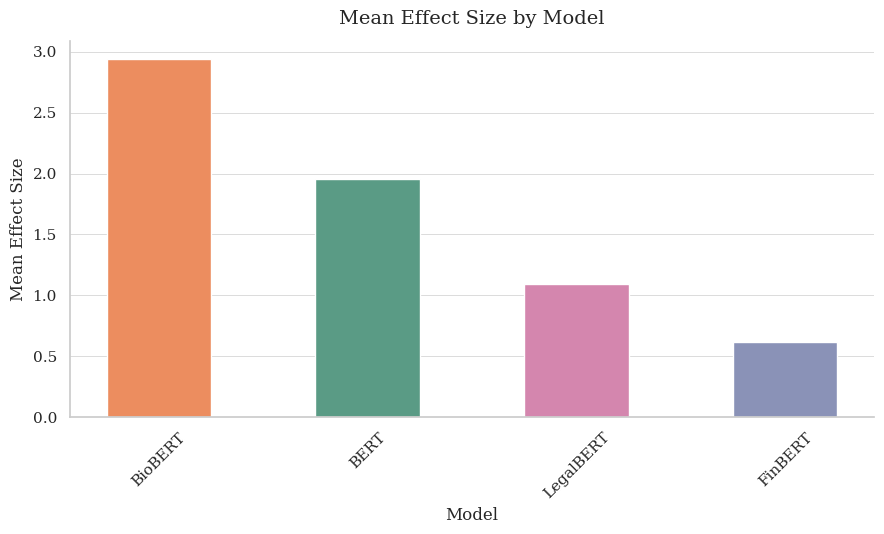

PAIRWISE WELCH'S t-TESTS  (Bonferroni-corrected α = 0.05)
Pair                                 t     df    p (raw)    p (adj)   Sig?
----------------------------------------------------------------------
BERT vs BioBERT                 -0.935    3.6     0.4090     1.0000      ✗
BERT vs FinBERT                  1.317    3.2     0.2739     1.0000      ✗
BERT vs LegalBERT                0.865    3.0     0.4505     1.0000      ✗
BioBERT vs FinBERT               6.155    1.6     0.0414     0.2484      ✗
BioBERT vs LegalBERT             5.668    1.0     0.1104     0.6623      ✗
FinBERT vs LegalBERT            -2.482    1.0     0.2412     1.0000      ✗
----------------------------------------------------------------------

Bonferroni correction: α_adj = 0.05 / 6 pairs = 0.0083


Summary table:
                pair  t_stat  dof  p_raw  p_adj  significant (Bonferroni)
     BERT vs BioBERT -0.9348  3.6 0.4090 1.0000                     False
     BERT vs FinBERT  1.3173  3.2 0.2739 1.0000       

In [50]:
# ============================================================
# 1. Mean Effect Size Bar Plot  (colour-matched to other plots)
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy import stats
from itertools import combinations

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
})

MODEL_COLORS = {
    'BERT':      '#5A9B85',   # teal-green
    'BioBERT':   '#EC8D5F',   # orange
    'FinBERT':   '#8A92B7',   # slate-blue
    'LegalBERT': '#D486AE',   # pink
}

# --- Plot ---
plot_data = df_results.groupby("model")["effect_size"].mean().sort_values(ascending=False)
colors    = [MODEL_COLORS[m] for m in plot_data.index]

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.bar(plot_data.index, plot_data.values, color=colors, width=0.5)

ax.set_xlabel("Model")
ax.set_ylabel("Mean Effect Size")
ax.set_title("Mean Effect Size by Model", pad=12)
ax.tick_params(axis='x', rotation=45)
ax.yaxis.grid(True, linestyle='-', linewidth=0.7, alpha=0.7)
ax.xaxis.grid(False)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('mean_effect_size.png', dpi=300, bbox_inches='tight')
plt.show()


# ============================================================
# 2. Statistical Significance Tests Between Models
# ============================================================
# Strategy:
#   Each model has one effect_size value per domain it was tested on.
#   We treat those per-domain effect sizes as the sample for each model
#   and run pairwise Welch's t-tests (unequal variance, unequal n).
#   We also apply Bonferroni correction for multiple comparisons.
#
#   Note: with only 2–4 observations per model the tests have low power;
#   interpret p-values alongside effect sizes.

models      = df_results['model'].unique()
model_pairs = list(combinations(models, 2))
n_pairs     = len(model_pairs)

print("=" * 70)
print("PAIRWISE WELCH'S t-TESTS  (Bonferroni-corrected α = 0.05)")
print("=" * 70)
print(f"{'Pair':<30} {'t':>7} {'df':>6} {'p (raw)':>10} {'p (adj)':>10} {'Sig?':>6}")
print("-" * 70)

sig_results = []

for m1, m2 in model_pairs:
    g1 = df_results[df_results['model'] == m1]['effect_size'].values
    g2 = df_results[df_results['model'] == m2]['effect_size'].values

    # Welch's t-test
    t_stat, p_raw = stats.ttest_ind(g1, g2, equal_var=False)

    # Degrees of freedom (Welch–Satterthwaite)
    n1, n2   = len(g1), len(g2)
    s1, s2   = g1.var(ddof=1), g2.var(ddof=1)
    dof      = (s1/n1 + s2/n2)**2 / ((s1/n1)**2/(n1-1) + (s2/n2)**2/(n2-1))

    # Bonferroni correction
    p_adj = min(p_raw * n_pairs, 1.0)
    sig   = "✓" if p_adj < 0.05 else "✗"

    pair_label = f"{m1} vs {m2}"
    print(f"{pair_label:<30} {t_stat:>7.3f} {dof:>6.1f} {p_raw:>10.4f} {p_adj:>10.4f} {sig:>6}")

    sig_results.append({
        'pair':   pair_label,
        't_stat': round(t_stat, 4),
        'dof':    round(dof, 1),
        'p_raw':  round(p_raw, 4),
        'p_adj':  round(p_adj, 4),
        'significant (Bonferroni)': sig == "✓"
    })

print("-" * 70)
print(f"\nBonferroni correction: α_adj = 0.05 / {n_pairs} pairs = {0.05/n_pairs:.4f}\n")

# --- Summary table ---
df_sig = pd.DataFrame(sig_results)
print("\nSummary table:")
print(df_sig.to_string(index=False))


# ============================================================
# 3. (Optional) One-Way ANOVA across all models
# ============================================================
# Tests the global null: all models have the same mean effect size.

groups   = [df_results[df_results['model'] == m]['effect_size'].values for m in models]
F, p_anova = stats.f_oneway(*groups)

print("\n" + "=" * 70)
print("ONE-WAY ANOVA (omnibus test)")
print("=" * 70)
print(f"  F-statistic : {F:.4f}")
print(f"  p-value     : {p_anova:.4f}")
print(f"  Result      : {'Significant difference exists between models (p < 0.05)' if p_anova < 0.05 else 'No significant difference detected (p ≥ 0.05)'}")
print()
print("  → If significant, use the pairwise Welch t-tests above to identify")
print("    which specific pairs differ.")
